In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

In [2]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.grid':        True,
    'grid.color':       'white',
    'grid.linewidth':   1.2,
    'font.family':      'monospace',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

COL_LLAMA = '#4C72B0'
COL_QWEN  = '#DD8452'
COL_FB    = '#C44E52'

In [3]:
df_llama = pd.read_csv('logs/llm_reward/LLAMA/rewards_log_LLAMA.csv')
df_qwen  = pd.read_csv('logs/llm_reward/QWEN/rewards_log_QWEN.csv')

df_llama['model'] = 'LLaMA 3.2:3b'
df_qwen['model']  = 'Qwen3:4b'

### Stats

In [4]:
def describe_reward(df, label):
    r_llm = df[df['source'] == 'llm']['reward']
    r_fb  = df[df['source'] == 'ppo_fallback']['reward']
    r_all = df['reward']

    rows = []
    for name, series in [('ALL', r_all), ('LLM only', r_llm), ('Fallback only', r_fb)]:
        if len(series) == 0:
            continue
        rows.append({
            'Model'    : label,
            'Subset'   : name,
            'N'        : len(series),
            'Mean'     : series.mean(),
            'Median'   : series.median(),
            'Std'      : series.std(),
            'Min'      : series.min(),
            'Max'      : series.max(),
            'Q1'       : series.quantile(0.25),
            'Q3'       : series.quantile(0.75),
            'Skewness' : series.skew(),
            'Kurtosis' : series.kurt(),
        })
    return rows

rows  = describe_reward(df_llama, 'LLaMA 3.2:3b')
rows += describe_reward(df_qwen,  'Qwen3:4b')

stats_df = pd.DataFrame(rows).set_index(['Model', 'Subset'])
float_cols = ['Mean','Median','Std','Min','Max','Q1','Q3','Skewness','Kurtosis']
display(stats_df[float_cols].style.format('{:.4f}').background_gradient(
    subset=['Mean','Std'], cmap='Blues'))

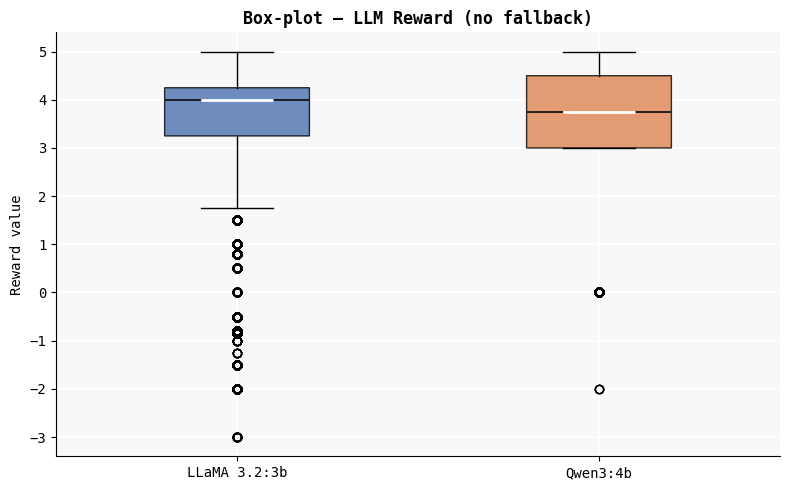

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

data_bp = [
    df_llama[df_llama['source'] == 'llm']['reward'].dropna().values,
    df_qwen[ df_qwen['source']  == 'llm']['reward'].dropna().values,
]
labels_bp = ['LLaMA 3.2:3b', 'Qwen3:4b']
colors_bp = [COL_LLAMA, COL_QWEN]

bp = ax.boxplot(data_bp, patch_artist=True, widths=0.4, notch=True,
                medianprops=dict(color='white', lw=2))
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_xticklabels(labels_bp)
ax.set_ylabel('Reward value')
ax.set_title('Box-plot — LLM Reward (no fallback)', fontweight='bold')
plt.tight_layout()
plt.savefig('reward_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

### Fallbacks per tags

In [6]:
TOP_N = 10

def fallback_by_state(df, label):
    fb  = df[df['source'] == 'ppo_fallback']
    tot = df.groupby('tag').size().rename('total_steps')
    fb_cnt = fb.groupby('tag').size().rename('fallback_count')
    result = pd.concat([tot, fb_cnt], axis=1).fillna(0)
    result['fallback_rate'] = result['fallback_count'] / result['total_steps']
    result['model'] = label
    return result.sort_values('fallback_count', ascending=False)

fb_llama = fallback_by_state(df_llama, 'LLaMA 3.2:3b')
fb_qwen  = fallback_by_state(df_qwen,  'Qwen3:4b')

print('\n=== Top-{} stati con più fallback — LLaMA ==='.format(TOP_N))
display(fb_llama.head(TOP_N)[['total_steps','fallback_count','fallback_rate']]
        .style.format({'fallback_rate': '{:.1%}'})
        .background_gradient(subset=['fallback_count'], cmap='Reds'))

print('\n=== Top-{} stati con più fallback — Qwen ==='.format(TOP_N))
display(fb_qwen.head(TOP_N)[['total_steps','fallback_count','fallback_rate']]
        .style.format({'fallback_rate': '{:.1%}'})
        .background_gradient(subset=['fallback_count'], cmap='Oranges'))


=== Top-10 stati con più fallback — LLaMA ===


,total_steps,fallback_count,fallback_rate
tag,,,
"HIT:HIT | ACT:LEFT | P1:APPR,RIGH,AWAY | P2:APPR,CENT,PARA",19,2.000000,10.5%
"HIT:HIT | ACT:LEFT | P1:DIST,CENT,PARA | P2:NONE",5,2.000000,40.0%
"HIT:HIT | ACT:RIGHT | P1:APPR,LEFT,AWAY | P2:APPR,LEFT,AWAY",31,2.000000,6.5%
"HIT:HIT | ACT:LEFT | P1:IMMI,LEFT,TOWA | P2:APPR,CENT,PARA",33,2.000000,6.1%
"HIT:HIT | ACT:LEFT | P1:IMMI,CENT,PARA | P2:IMMI,RIGH,AWAY",6,2.000000,33.3%
"HIT:NONE | ACT:RIGHT | P1:IMMI,LEFT,AWAY | P2:DIST,CENT,PARA",7,2.000000,28.6%
"HIT:HIT | ACT:LEFT | P1:IMMI,LEFT,TOWA | P2:IMMI,LEFT,TOWA",60,1.000000,1.7%
"HIT:HIT | ACT:LEFT | P1:IMMI,RIGH,AWAY | P2:APPR,LEFT,TOWA",53,1.000000,1.9%
"HIT:HIT | ACT:RIGHT | P1:APPR,RIGH,TOWA | P2:DIST,LEFT,AWAY",3,1.000000,33.3%



=== Top-10 stati con più fallback — Qwen ===


,total_steps,fallback_count,fallback_rate
tag,,,
"HIT:HIT | ACT:RIGHT | P1:IMMI,RIGH,TOWA | P2:DIST,LEFT,AWAY",4,4.000000,100.0%
"HIT:HIT | ACT:RIGHT | P1:IMMI,CENT,PARA | P2:APPR,RIGH,TOWA",7,3.000000,42.9%
"HIT:NONE | ACT:RIGHT | P1:APPR,CENT,PARA | P2:DIST,LEFT,AWAY",3,3.000000,100.0%
"HIT:NONE | ACT:LEFT | P1:IMMI,LEFT,TOWA | P2:DIST,RIGH,AWAY",4,3.000000,75.0%
"HIT:HIT | ACT:LEFT | P1:APPR,CENT,PARA | P2:DIST,LEFT,TOWA",4,3.000000,75.0%
"HIT:NONE | ACT:RIGHT | P1:APPR,CENT,PARA | P2:DIST,CENT,PARA",7,3.000000,42.9%
"HIT:NONE | ACT:RIGHT | P1:IMMI,CENT,PARA | P2:DIST,CENT,PARA",3,3.000000,100.0%
"HIT:HIT | ACT:LEFT | P1:IMMI,LEFT,TOWA | P2:DIST,RIGH,AWAY",3,2.000000,66.7%
"HIT:HIT | ACT:RIGHT | P1:IMMI,CENT,PARA | P2:NONE",5,2.000000,40.0%


### Inter-model comparison

In [8]:
fb_states_llama = set(fb_llama[fb_llama['fallback_count'] > 0].index)
fb_states_qwen  = set(fb_qwen[ fb_qwen['fallback_count']  > 0].index)

shared     = fb_states_llama & fb_states_qwen
only_llama = fb_states_llama - fb_states_qwen
only_qwen  = fb_states_qwen  - fb_states_llama

print(f'Stati con fallback in ENTRAMBI i modelli : {len(shared):>5}')
print(f'Fallback solo in LLaMA                  : {len(only_llama):>5}')
print(f'Fallback solo in Qwen                   : {len(only_qwen):>5}')

# Heatmap sintetica: fallback_rate nei top-30 stati condivisi
if len(shared) > 0:
    shared_list = list(shared)
    compare = pd.DataFrame({
        'LLaMA fallback_rate': fb_llama.loc[fb_llama.index.isin(shared_list), 'fallback_rate'],
        'Qwen fallback_rate':  fb_qwen.loc[ fb_qwen.index.isin(shared_list),  'fallback_rate'],
    }).sort_values('LLaMA fallback_rate', ascending=False).head(30)
    display(compare.style.format('{:.1%}').background_gradient(cmap='Reds'))

Stati con fallback in ENTRAMBI i modelli :     7
Fallback solo in LLaMA                  :    25
Fallback solo in Qwen                   :    34


,LLaMA fallback_rate,Qwen fallback_rate
tag,,
"HIT:NONE | ACT:RIGHT | P1:IMMI,CENT,PARA | P2:DIST,CENT,PARA",33.3%,100.0%
"HIT:HIT | ACT:LEFT | P1:IMMI,LEFT,TOWA | P2:DIST,RIGH,AWAY",12.5%,66.7%
"HIT:HIT | ACT:LEFT | P1:DIST,LEFT,TOWA | P2:NONE",10.0%,20.0%
"HIT:HIT | ACT:LEFT | P1:IMMI,CENT,PARA | P2:APPR,LEFT,TOWA",10.0%,33.3%
"HIT:HIT | ACT:LEFT | P1:APPR,CENT,PARA | P2:NONE",2.3%,5.6%
"HIT:NONE | ACT:RIGHT | P1:APPR,CENT,PARA | P2:APPR,CENT,PARA",0.6%,1.5%
"HIT:NONE | ACT:RIGHT | P1:IMMI,CENT,PARA | P2:IMMI,RIGH,TOWA",0.1%,0.1%
